# Make pseudobulk bigwig files

In [61]:
import pandas as pd
import anndata as ad
import numpy as np
import scanpy as scan
import os
import pyBigWig
import pybedtools
from collections import defaultdict
from pathlib import Path

In [ ]:
!pip install scanpy pyBigWig pybedtools

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.2/75.2 kB 3.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 5.5 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 5.2 MB/s eta 0:00:0000:0100:01
Using cached networkx-3.4.2-py3-none-any.whl (1.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 5.7 MB/s eta 0:00:0000:0100:01
  Created wheel for pyBigWig: filename=pybigwig-0.3.24-cp312-cp312-macosx_11_0_arm64.whl size=62510 sha256=751fe789c58fe3d6d91a72cc88c35acc5d6381044e149a14bf3a6ced05abeb80
  Stored in directory: /Users/artemilin/Library/Caches/pip/wheels/0d/23/3e/3c4b2cf5c1dd491f9ec6c6

In [2]:
import sys

sys.path.append('/Users/artemilin/Work/projects/scCandT//toolkit-project')
import src as toolkit

In [7]:
toolkit.set_defaults(figsize = (7,7))

## Preprocessing and preparation

### Load data

In [30]:
!readlink -f ../h5ad/wt_mutant_combined.h5ad

/Users/artemilin/Work/projects/Landscapes/scCandT/h5ad/wt_mutant_combined.h5ad


In [5]:
ctad = ad.read_h5ad("../h5ad/wt_mutant_combined.h5ad")

In [6]:
harm = pd.read_csv("/Users/artemilin/R/projects/EmbryoEpi/csv/harmony_embeddings.csv", index_col=0)

# make sure rows align with adata.obs_names
harm = harm.loc[ctad.obs_names]

# add as obsm
ctad.obsm["X_harmony"] = harm.values

In [7]:
ctad

AnnData object with n_obs × n_vars = 22139 × 24097
    obs: 'acet_total_counts', 'acet_log_total_counts', 'meth_total_counts', 'meth_log_total_counts', 'exclude', 'leiden', 'cond', 'batch', 'wt_lab', 'label'
    var: 'acet_total_counts', 'acet_log_total_counts', 'meth_total_counts', 'meth_log_total_counts', 'chr', 'start', 'end', 'exclude'
    uns: 'colors_dict', 'gene_names_acet_binary', 'gene_names_meth_binary'
    obsm: 'X_acetylation', 'X_methylation', 'X_multi_spectral', 'X_spectral', 'X_umap', 'acet', 'acet_binary', 'meth', 'meth_binary', 'X_harmony'
    layers: 'acet', 'acet_binary', 'meth', 'meth_binary'
    obsp: 'connectivities', 'distances'

In [34]:
pd.DataFrame(ctad.obsm["X_multi_spectral"], index=ctad.obs_names).to_csv("../metadata/wt_kd_Xms.csv")

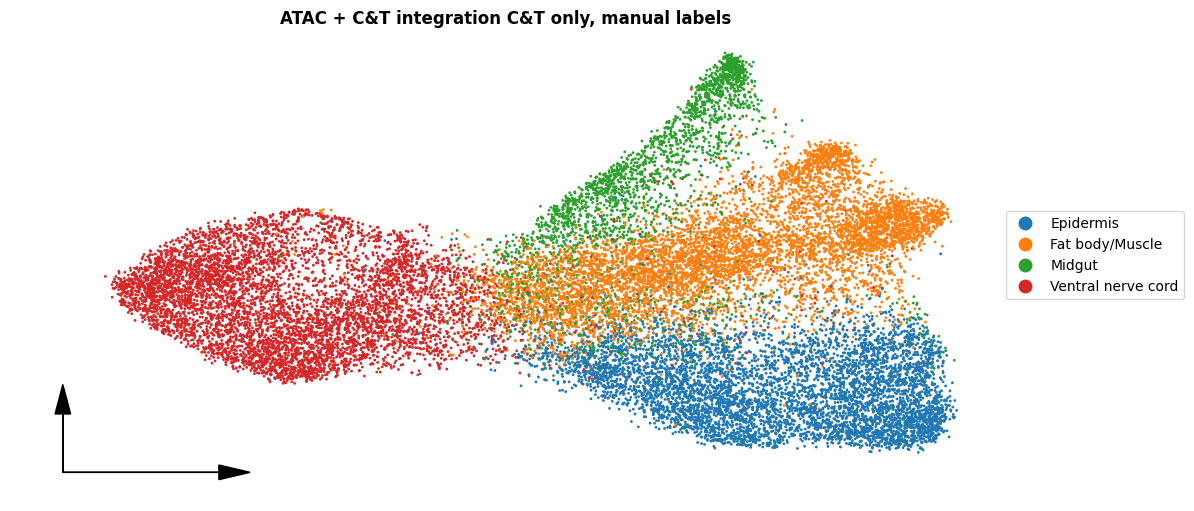

In [6]:
toolkit.pl.embedding2d(ctad, "X_umap", "label", size = 1, title = 'ATAC + C&T integration C&T only, manual labels')

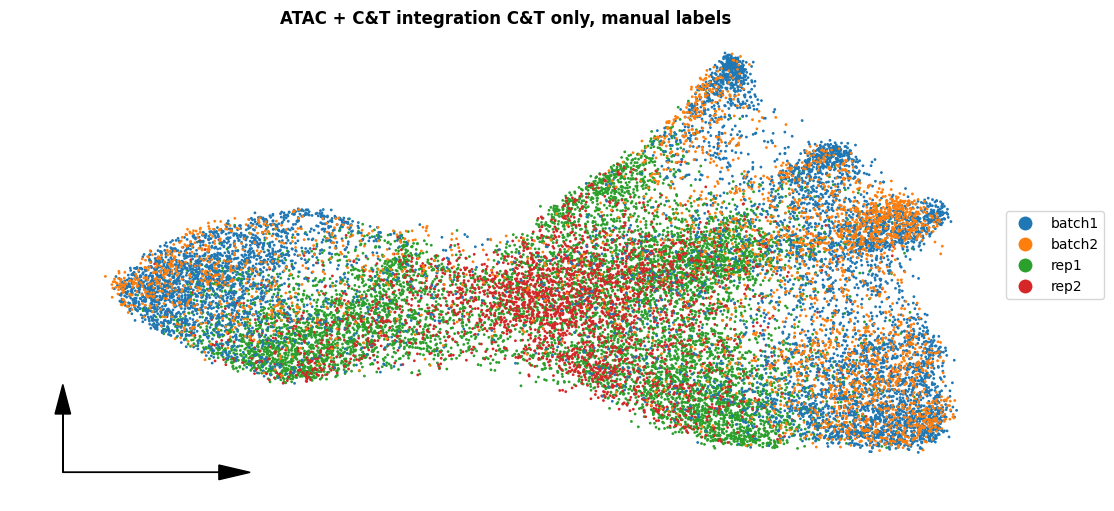

In [9]:
toolkit.pl.embedding2d(ctad, "X_umap", "batch", size = 1, title = 'ATAC + C&T integration C&T only, manual labels')

In [12]:
toolkit.em.umap(ctad, 'X_harmony')
toolkit.gr.knn(ctad, "X_harmony", n_neighbors=5)

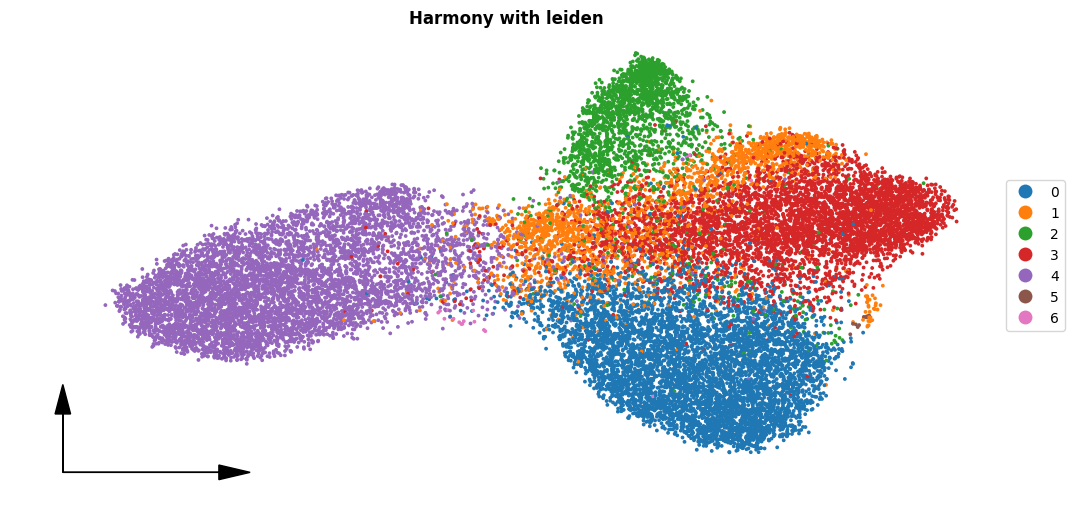

In [23]:
g = toolkit.gr.neighbor_graph(ctad)
toolkit.gr.leiden(ctad, g, 0.7)
toolkit.pl.embedding2d(ctad, 'X_umap', 'leiden', title=f'Harmony with leiden')

In [27]:
ctad.write_h5ad("../h5ad/wt_kd_1416h_harmony_leiden.h5ad")

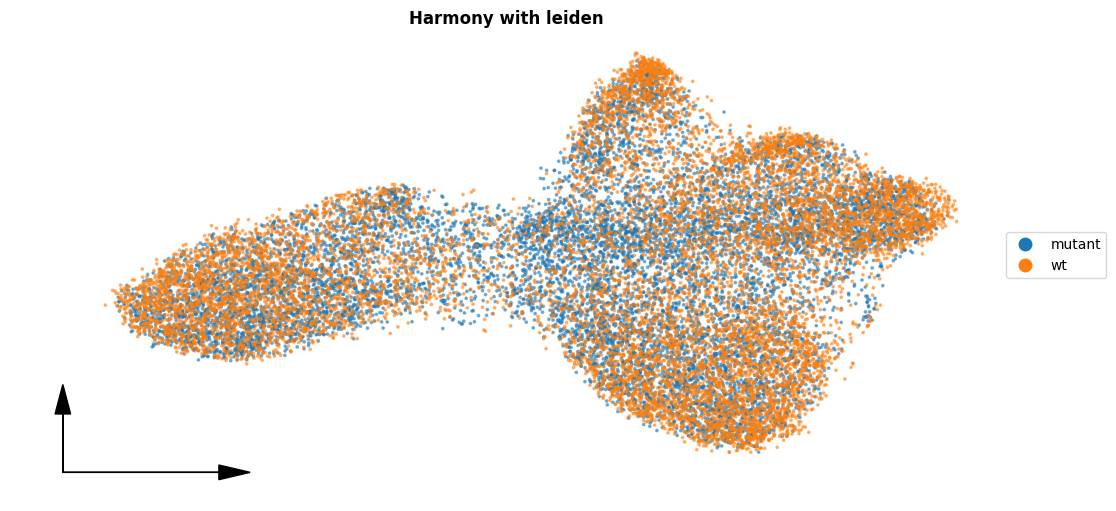

In [26]:
toolkit.pl.embedding2d(ctad, 'X_umap', 'cond', title=f'Harmony with leiden', alpha = 0.5)

In [12]:
ctad = ctad[ctad.obs['cond'] == 'mutant']
ctad.obs

,acet_total_counts,acet_log_total_counts,meth_total_counts,meth_log_total_counts,exclude,leiden,cond,batch,wt_lab,label
AAACGAAAGTACAACA-1R1,274,5.616771,294,5.686975,False,0,mutant,rep1,None,Epidermis
AAACGAAAGTTCGACT-1R1,145,4.983607,109,4.700480,False,2,mutant,rep1,None,Midgut
AAACGAACAAGGAGGG-1R1,378,5.937536,213,5.365976,False,2,mutant,rep1,None,Midgut
AAACGAACAAGTCTCA-1R1,263,5.575949,173,5.159055,False,4,mutant,rep1,None,Fat body/Muscle
AAACGAACAATCAGGG-1R1,106,4.672829,51,3.951244,False,4,mutant,rep1,None,Fat body/Muscle
...,...,...,...,...,...,...,...,...,...,...
TTTGTGTAGGAGAACA-1R2,594,6.388561,509,6.234411,False,2,mutant,rep2,None,Midgut
TTTGTGTAGGCACCTC-1R2,801,6.687109,479,6.173786,False,4,mutant,rep2,None,Fat body/Muscle
TTTGTGTCACTCCACT-1R2,343,5.840642,219,5.393628,False,4,mutant,rep2,None,Fat body/Muscle
TTTGTGTCAGGCTACC-1R2,86,4.465908,44,3.806662,False,4,mutant,rep2,None,Fat body/Muscle


### Get the original barcode formatting from .obs.index

In [15]:
ctad.obs['barcode'] = [idx[:-3] + '1' for idx in ctad.obs.index]
ctad.obs

,acet_total_counts,acet_log_total_counts,meth_total_counts,meth_log_total_counts,exclude,leiden,cond,batch,wt_lab,label,barcode
AAACGAAAGTACAACA-1R1,274,5.616771,294,5.686975,False,0,mutant,rep1,None,Epidermis,AAACGAAAGTACAACA-1
AAACGAAAGTTCGACT-1R1,145,4.983607,109,4.700480,False,2,mutant,rep1,None,Midgut,AAACGAAAGTTCGACT-1
AAACGAACAAGGAGGG-1R1,378,5.937536,213,5.365976,False,2,mutant,rep1,None,Midgut,AAACGAACAAGGAGGG-1
AAACGAACAAGTCTCA-1R1,263,5.575949,173,5.159055,False,4,mutant,rep1,None,Fat body/Muscle,AAACGAACAAGTCTCA-1
AAACGAACAATCAGGG-1R1,106,4.672829,51,3.951244,False,4,mutant,rep1,None,Fat body/Muscle,AAACGAACAATCAGGG-1
...,...,...,...,...,...,...,...,...,...,...,...
TTTGTGTAGGAGAACA-1R2,594,6.388561,509,6.234411,False,2,mutant,rep2,None,Midgut,TTTGTGTAGGAGAACA-1
TTTGTGTAGGCACCTC-1R2,801,6.687109,479,6.173786,False,4,mutant,rep2,None,Fat body/Muscle,TTTGTGTAGGCACCTC-1
TTTGTGTCACTCCACT-1R2,343,5.840642,219,5.393628,False,4,mutant,rep2,None,Fat body/Muscle,TTTGTGTCACTCCACT-1
TTTGTGTCAGGCTACC-1R2,86,4.465908,44,3.806662,False,4,mutant,rep2,None,Fat body/Muscle,TTTGTGTCAGGCTACC-1


### Keep only the labels of interest

In [67]:
ctad = ctad[ctad.obs.cond == 'mutant']

In [ ]:
ctad.obs["batch"].value_counts()

batch
rep1    8723
rep2    2877
Name: count, dtype: int64

In [70]:
ctad.obs['label'] = ctad.obs['label'].cat.rename_categories({'Fat body/Muscle': 'Mesoderm'})

/var/folders/hg/9jt35chj7c93_pv8k103v49c0000gn/T/ipykernel_55109/4167822182.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  ctad.obs['label'] = ctad.obs['label'].cat.rename_categories({'Fat body/Muscle': 'Mesoderm'})


In [71]:
labels = ctad.obs['label'].unique()
for i in labels:
    print(i)

Epidermis
Midgut
Mesoderm
Ventral nerve cord


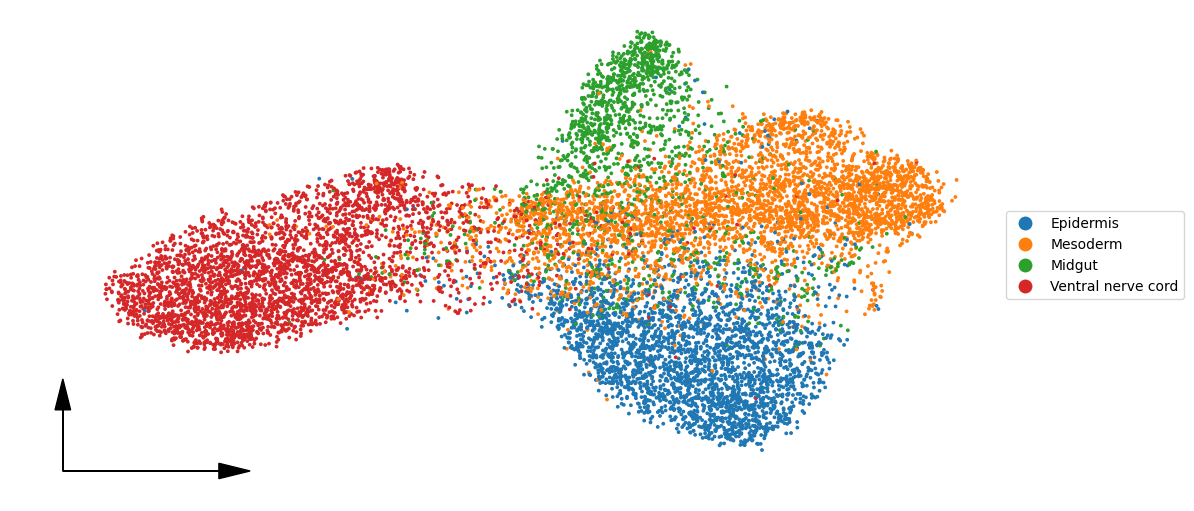

In [72]:
# ctad2.obs['outside'] = ctad2.obsm['X_umap'][:,1] > 9.5
toolkit.pl.embedding2d(ctad, 'X_umap', 'label')

### Prepare CSV files with barcodes for each fragment file and cluster

In [24]:
# Ensure output directory exists
output_dir = "../pseudobulk_ezkd_csv"
os.makedirs(output_dir, exist_ok=True)

# Iterate over all combinations of 'batch' and 'timep'
for batch, group in ctad.obs.groupby("batch"):
    # Create a folder for the combination
    folder_path = os.path.join(output_dir, f"{batch}")
    os.makedirs(folder_path, exist_ok=True)

    # Filter and save CSV files for each label of interest
    for label in labels:
        # Filter the DataFrame for the current label
        filtered = group[group["label"] == label]

        # If there are rows, save them
        if not filtered.empty:
            safe_label = label.replace(" ", "_")
            csv_path = os.path.join(folder_path, f"{safe_label}.csv")
            filtered[["barcode"]].to_csv(csv_path, index=False, header=False)
            print(f"Saved {csv_path}")

Saved ../pseudobulk_ezkd_csv/rep1/Epidermis.csv
Saved ../pseudobulk_ezkd_csv/rep1/Midgut.csv
Saved ../pseudobulk_ezkd_csv/rep1/Mesoderm.csv
Saved ../pseudobulk_ezkd_csv/rep1/Ventral_nerve_cord.csv
Saved ../pseudobulk_ezkd_csv/rep2/Epidermis.csv
Saved ../pseudobulk_ezkd_csv/rep2/Midgut.csv
Saved ../pseudobulk_ezkd_csv/rep2/Mesoderm.csv
Saved ../pseudobulk_ezkd_csv/rep2/Ventral_nerve_cord.csv


/var/folders/hg/9jt35chj7c93_pv8k103v49c0000gn/T/ipykernel_38838/3636660646.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for batch, group in ctad.obs.groupby("batch"):


In [25]:
os.listdir("../pseudobulk_ezkd_csv/rep1/")

['Ventral_nerve_cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Mesoderm.csv']

In [33]:
!rm /Users/artemilin/Work/projects/Landscapes/scCandT/nanoCT_ezkd/fragments/.DS_Store

In [34]:
os.listdir("/Users/artemilin/Work/projects/Landscapes/scCandT/nanoCT_ezkd/fragments/")

['emb14_16h_h3k27me3_1_fragments.tsv',
 'emb14_16h_h3k27me3_2_fragments.tsv',
 'emb14_16h_h3k27ac_1_fragments.tsv',
 'emb14_16h_h3k27ac_2_fragments.tsv']

In [ ]:
os.listdir("../fragments/nanoct/rep1/")

['emb14_16h_h3k27me3_1_fragments.tsv',
 'emb8_10h_h3k27ac_1_fragments.tsv',
 'emb8_10h_h3k27me3_1_fragments.tsv',
 'emb14_16h_h3k27ac_1_fragments.tsv']

In [28]:
chrom_sizes = [("chr2L", 23513712),
               ("chr2R", 25286936),
               ("chr3L", 28110227),
               ("chr3R", 32079331),
               ("chr4", 1348131),
               ("chrX", 23542271),
              ("chrY", 3667352)]  

In [25]:
!mkdir ../files_etc

In [27]:
!echo -e "chr2L\t23513712\nchr2R\t25286936\nchr3L\t28110227\nchr3R\t32079331\nchrX\t23542271" > ../files_etc/dm6.chrom.sizes


In [30]:
def read_fragment_file(bed_file):
    """Read a fragments file into a pandas DataFrame."""
    cols = ["chr", "start", "end", "read"]
    df = pd.read_csv(bed_file, sep="\t", header=None, usecols=[0, 1, 2, 3], names=cols, comment="#")
    df["chr"] = df["chr"].astype(str).apply(lambda x: x if x.startswith("chr") else f"chr{x}")
    return df

def filter_reads(bed_df, read_names_file):
    """Filter reads based on a read names file."""
    with open(read_names_file, "r") as f:
        valid_reads = set(line.strip() for line in f)

    # Assuming the BED file has a read name in column 3 (adjust if necessary)
    return bed_df[bed_df["read"].astype(str).isin(valid_reads)]

def create_bigwig(filtered_bed_path, windows_path, output_bw, chrom_sizes, norm = 1):
    """Convert the filtered BED data to a BigWig coverage track."""
    bedf = pybedtools.bedtool.BedTool(filtered_bed_path)
    bedsrt = bedf.sort()
    windf = pybedtools.bedtool.BedTool(windows_path)
    cov = windf.coverage(bedsrt)
    df = cov.to_dataframe(names=['chrom', 'start', 'end', 'depth', 'n', 'chromsize', 'fraction'])
    df = df[(df['depth'] > 0) & (df['chrom'].isin([i[0] for i in chrom_sizes]))]
    
    bw = pyBigWig.open(output_bw, "w")

    # Define chromosome sizes (adjust accordingly)
    bw.addHeader(chrom_sizes)

    bw.addEntries(
        df['chrom'].tolist(),
        starts = (df['start'] + 1).tolist(),
        ends = df['end'].tolist(),
        values = (df['depth']/norm).astype('float').tolist()
    )

    bw.close()


In [31]:
def absoluteFilePaths(directory):
    for dirpath,_,filenames in os.walk(directory):
        for f in filenames:
            yield os.path.abspath(os.path.join(dirpath, f))

In [32]:
frag_path = "/Users/artemilin/Work/projects/Landscapes/scCandT/nanoCT_ezkd/fragments/"
frags = [i for i in absoluteFilePaths(frag_path)]

In [33]:
csv_dirs = os.listdir("../pseudobulk_ezkd_csv/")

In [34]:
csv_dirs.sort()

In [35]:
csv_dirs

['rep1', 'rep2']

In [36]:
frags.sort()
frags = [frags[0], frags[2], frags[1], frags[3]]
frags

['/Users/artemilin/Work/projects/Landscapes/scCandT/nanoCT_ezkd/fragments/emb14_16h_h3k27ac_1_fragments.tsv',
 '/Users/artemilin/Work/projects/Landscapes/scCandT/nanoCT_ezkd/fragments/emb14_16h_h3k27me3_1_fragments.tsv',
 '/Users/artemilin/Work/projects/Landscapes/scCandT/nanoCT_ezkd/fragments/emb14_16h_h3k27ac_2_fragments.tsv',
 '/Users/artemilin/Work/projects/Landscapes/scCandT/nanoCT_ezkd/fragments/emb14_16h_h3k27me3_2_fragments.tsv']

In [37]:
ps_dir = "../pseudobulk_ezkd_csv"

In [38]:
csv_dirs = [os.path.abspath(os.path.join(ps_dir, f)) for f in os.listdir(ps_dir)]

In [39]:
csv_dirs.sort()
csv_dirs

['/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep1',
 '/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep2']

In [51]:
# Check that fragments and csv files are in the correct order
# 1. Frags
import re
pattern1 = r"(\d+_\d+).*?_(\d+)_"

# Extract values while maintaining order
extracted1 = [match.groups() for path in frags if (match := re.search(pattern1, path))]
# Flatten and get unique items while preserving order
unique_results1 = list(dict.fromkeys(extracted1))

pattern2 = r"rep([12])"
extracted2 = [match.groups()[::-1] for path in csv_dirs if (match := re.search(pattern2, path))]
assert(unique_results1 == extracted2)


AssertionError: 

In [40]:
os.listdir(csv_dirs[0])

['Ventral_nerve_cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Mesoderm.csv']

In [41]:
frags_csv = {}
frags_csv[csv_dirs[0]] = frags[0:2]
frags_csv[csv_dirs[1]] = frags[2:]
frags_csv

{'/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep1': ['/Users/artemilin/Work/projects/Landscapes/scCandT/nanoCT_ezkd/fragments/emb14_16h_h3k27ac_1_fragments.tsv',
  '/Users/artemilin/Work/projects/Landscapes/scCandT/nanoCT_ezkd/fragments/emb14_16h_h3k27me3_1_fragments.tsv'],
 '/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep2': ['/Users/artemilin/Work/projects/Landscapes/scCandT/nanoCT_ezkd/fragments/emb14_16h_h3k27ac_2_fragments.tsv',
  '/Users/artemilin/Work/projects/Landscapes/scCandT/nanoCT_ezkd/fragments/emb14_16h_h3k27me3_2_fragments.tsv']}

In [42]:
frags_csv

{'/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep1': ['/Users/artemilin/Work/projects/Landscapes/scCandT/nanoCT_ezkd/fragments/emb14_16h_h3k27ac_1_fragments.tsv',
  '/Users/artemilin/Work/projects/Landscapes/scCandT/nanoCT_ezkd/fragments/emb14_16h_h3k27me3_1_fragments.tsv'],
 '/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep2': ['/Users/artemilin/Work/projects/Landscapes/scCandT/nanoCT_ezkd/fragments/emb14_16h_h3k27ac_2_fragments.tsv',
  '/Users/artemilin/Work/projects/Landscapes/scCandT/nanoCT_ezkd/fragments/emb14_16h_h3k27me3_2_fragments.tsv']}

### Make 50 nt genomic windows on dm6 genome

In [27]:
a = pybedtools.bedtool.BedTool()
b = a.makewindows(genome = "dm6", w = 50)

In [28]:
b.saveas("../bed/dm6.chromios.bed")

<BedTool(../bed/dm6.chromios.bed)>

## Start producing pseudobulk profiles bigwigs
### Pool together fragment files from both replicates for separate modalities and time points

In [78]:
import os
import pandas as pd

# Dictionary to store bed files by time point, modality, and cluster
bed_files = {}
# Dictionary for normalization factors
fragkeys = list(frags_csv.keys())

for csvf in frags_csv.keys():
    print(csvf)
    
    # 1. H3K27ac
    ac_frag_p = next((s for s in frags_csv[csvf] if "h3k27ac" in s), None)
    ac_base = os.path.basename(ac_frag_p).replace("_fragments.tsv", "")
    ac_frag = read_fragment_file(ac_frag_p)

    # 2. H3K27me3
    meth_frag_p = next((s for s in frags_csv[csvf] if "h3k27me" in s), None)
    meth_base = os.path.basename(meth_frag_p).replace("_fragments.tsv", "")
    meth_frag = read_fragment_file(meth_frag_p)

    for read_l_base in os.listdir(csvf):
        cluster_bw = read_l_base.replace("csv", "bw")
        read_list = os.path.join(csvf, read_l_base)

        # Extract time point and cluster identifier
        time_point = "8_10h" if "8_10h" in csvf else "14_16h"
        cluster_id = os.path.splitext(read_l_base)[0]

        for modality, frag, base in [("h3k27ac", ac_frag, ac_base), ("h3k27me3", meth_frag, meth_base)]:
            temp_bed = f"../bed_ezkd/{base}_{cluster_id}_temp.bed"
            filtered_reads = filter_reads(frag, read_list)
            filtered_reads.iloc[:, 0:3].to_csv(temp_bed, sep="\t", index=False, header=False)
            
            # Store bed files by (time_point, modality, cluster)
            key = (time_point, modality, cluster_id)
            if key not in bed_files:
                bed_files[key] = []
            bed_files[key].append(temp_bed)

    # print([ac_frag_p, meth_frag_p])



/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep1
/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep2


### Normalize bigwig profiles on cluster size at a given time point
Normalization coefficient is equal to (cluster_size)/1000, because the largest cluster consists of ~8000 cells
For no normalization, don't use norm parameter in create_bigwig function or set it to 1.

In [79]:
bed_files.items()

dict_items([(('14_16h', 'h3k27ac', 'Ventral_nerve_cord'), ['../bed_ezkd/emb14_16h_h3k27ac_1_Ventral_nerve_cord_temp.bed', '../bed_ezkd/emb14_16h_h3k27ac_2_Ventral_nerve_cord_temp.bed']), (('14_16h', 'h3k27me3', 'Ventral_nerve_cord'), ['../bed_ezkd/emb14_16h_h3k27me3_1_Ventral_nerve_cord_temp.bed', '../bed_ezkd/emb14_16h_h3k27me3_2_Ventral_nerve_cord_temp.bed']), (('14_16h', 'h3k27ac', 'Midgut'), ['../bed_ezkd/emb14_16h_h3k27ac_1_Midgut_temp.bed', '../bed_ezkd/emb14_16h_h3k27ac_2_Midgut_temp.bed']), (('14_16h', 'h3k27me3', 'Midgut'), ['../bed_ezkd/emb14_16h_h3k27me3_1_Midgut_temp.bed', '../bed_ezkd/emb14_16h_h3k27me3_2_Midgut_temp.bed']), (('14_16h', 'h3k27ac', 'Epidermis'), ['../bed_ezkd/emb14_16h_h3k27ac_1_Epidermis_temp.bed', '../bed_ezkd/emb14_16h_h3k27ac_2_Epidermis_temp.bed']), (('14_16h', 'h3k27me3', 'Epidermis'), ['../bed_ezkd/emb14_16h_h3k27me3_1_Epidermis_temp.bed', '../bed_ezkd/emb14_16h_h3k27me3_2_Epidermis_temp.bed']), (('14_16h', 'h3k27ac', 'Mesoderm'), ['../bed_ezkd/emb14

In [2]:
!mkdir ../bw_norm_cs_ezkd

mkdir: ../bw_norm_cs_ezkd: File exists


In [24]:
csv_walk = [list(os.walk(k)) for k in fragkeys]
[os.path.join(dirpath, file) for batch in csv_walk for dirpath, _, files in batch for file in files]

['/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep1/Ventral_nerve_cord.csv',
 '/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep1/Midgut.csv',
 '/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep1/Epidermis.csv',
 '/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep1/Mesoderm.csv',
 '/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep2/Ventral_nerve_cord.csv',
 '/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep2/Midgut.csv',
 '/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep2/Epidermis.csv',
 '/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep2/Mesoderm.csv']

In [27]:
# Folder name for saving the outputs
bwf = 'bw_norm_cs_ezkd'
# Merge and create BigWig files
for (time_point, modality, cluster_id), beds in bed_files.items():
    merged_bed = f"../bed/{time_point}_{modality}_{cluster_id}_merged.bed"
    merged_bw = f"../{bwf}/{time_point}_{modality}_{cluster_id}.bw"

    # Merge BED files
    bed_dfs = [pd.read_csv(b, sep="\t", header=None) for b in beds]
    merged_df = pd.concat(bed_dfs, ignore_index=True)
    merged_df.to_csv(merged_bed, sep="\t", index=False, header=False)

    # Get normalization coefficient
    csv_walk = [list(os.walk(k)) for k in fragkeys]
    print(csv_walk)
    csv_path = [os.path.join(dirpath, file) for batch in csv_walk for dirpath, _, files in batch for file in files]
    bc_cluster = [k for k in csv_path if cluster_id in k]
    normc = sum(sum(1 for _ in open(file, "r")) for file in bc_cluster)/1000
    print(normc)

    # Create BigWig
    create_bigwig(merged_bed, "../bed/dm6.chromios.bed", merged_bw, chrom_sizes, norm=normc)

[[('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep1', [], ['Ventral_nerve_cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Mesoderm.csv'])], [('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep2', [], ['Ventral_nerve_cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Mesoderm.csv'])]]
3.387
[[('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep1', [], ['Ventral_nerve_cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Mesoderm.csv'])], [('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep2', [], ['Ventral_nerve_cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Mesoderm.csv'])]]
3.387
[[('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep1', [], ['Ventral_nerve_cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Mesoderm.csv'])], [('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep2', [], ['Ventral_nerve_cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Mesoderm.csv'])]]
1.521
[[('/Users/ar

### Normalize on total fragment number x cell size

In [45]:
totfmet = 0
totfac = 0
for (time_point, modality, cluster_id), beds in bed_files.items():
    if modality == "h3k27me3":
        merged_bed = f"../bed/{time_point}_{modality}_{cluster_id}_merged.bed"
        print(merged_bed)
        totfmet += sum(1 for _ in open(merged_bed, "r"))
    else:
        merged_bed = f"../bed/{time_point}_{modality}_{cluster_id}_merged.bed"
        print(merged_bed)
        totfac += sum(1 for _ in open(merged_bed, "r"))

print(f'Total nfrag for meth: {totfmet}, total nfrag for acet: {totfac}')

../bed/14_16h_h3k27ac_Ventral_nerve_cord_merged.bed
../bed/14_16h_h3k27me3_Ventral_nerve_cord_merged.bed
../bed/14_16h_h3k27ac_Midgut_merged.bed
../bed/14_16h_h3k27me3_Midgut_merged.bed
../bed/14_16h_h3k27ac_Epidermis_merged.bed
../bed/14_16h_h3k27me3_Epidermis_merged.bed
../bed/14_16h_h3k27ac_Mesoderm_merged.bed
../bed/14_16h_h3k27me3_Mesoderm_merged.bed
Total nfrag for meth: 2597442, total nfrag for acet: 3810275


In [50]:
%mkdir ../bw_norm_totfrcs_ezkd

mkdir: ../bw_norm_totfrcs_ezkd: File exists


In [51]:
# Folder name for saving the outputs
bwf = 'bw_norm_totfrcs_ezkd'
# Merge and create BigWig files
for (time_point, modality, cluster_id), beds in bed_files.items():
    merged_bed = f"../bed/{time_point}_{modality}_{cluster_id}_merged.bed"
    merged_bw = f"../{bwf}/EZKD_nbyTotFrClSize{time_point}_{modality}_{cluster_id}.bw"

    # Merge BED files
    bed_dfs = [pd.read_csv(b, sep="\t", header=None) for b in beds]
    merged_df = pd.concat(bed_dfs, ignore_index=True)
    merged_df.to_csv(merged_bed, sep="\t", index=False, header=False)

    # Get normalization coefficient
    csv_walk = [list(os.walk(k)) for k in fragkeys]
    print(csv_walk)
    csv_path = [os.path.join(dirpath, file) for batch in csv_walk for dirpath, _, files in batch for file in files]
    bc_cluster = [k for k in csv_path if cluster_id in k]
    if modality == 'h3k27me3':
        normc = sum(sum(1 for _ in open(file, "r")) for file in bc_cluster)*totfmet/1000000000
    else:
        normc = sum(sum(1 for _ in open(file, "r")) for file in bc_cluster)*totfac/1000000000

    print(normc)

    # Create BigWig
    create_bigwig(merged_bed, "../bed/dm6.chromios.bed", merged_bw, chrom_sizes, norm=normc)

[[('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep1', [], ['Ventral_nerve_cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Mesoderm.csv'])], [('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep2', [], ['Ventral_nerve_cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Mesoderm.csv'])]]
12.905401425
[[('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep1', [], ['Ventral_nerve_cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Mesoderm.csv'])], [('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep2', [], ['Ventral_nerve_cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Mesoderm.csv'])]]
8.797536054
[[('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep1', [], ['Ventral_nerve_cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Mesoderm.csv'])], [('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep2', [], ['Ventral_nerve_cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Mesoderm.csv'])]]
5.7954

### Normalize bigwig profiles on the number of fragments at a given time point
Normalization coefficient is equal to ()/1000, because the largest cluster consists of ~8000 cells
For no normalization, don't use norm parameter in create_bigwig function or set it to 1.

In [ ]:
!mkdir ../bw_norm_by_frag_ezkd

In [ ]:
# Folder name for saving the outputs
bwf = 'bw_norm_by_frag_ezkd'
# Merge and create BigWig files
for (time_point, modality, cluster_id), beds in bed_files.items():
    merged_bed = f"../bed/{time_point}_{modality}_{cluster_id}_merged.bed"
    merged_bw = f"../{bwf}/{time_point}_{modality}_{cluster_id}.bw"

    # Merge BED files
    bed_dfs = [pd.read_csv(b, sep="\t", header=None) for b in beds]
    merged_df = pd.concat(bed_dfs, ignore_index=True)
    merged_df.to_csv(merged_bed, sep="\t", index=False, header=False)

    # Get normalization coefficient
    csv_walk = [list(os.walk(k)) for k in fragkeys]
    csv_path = [os.path.join(dirpath, file) for batch in csv_walk for dirpath, _, files in batch for file in files]
    bc_cluster = [k for k in csv_path if cluster_id in k]
    normc = sum(1 for _ in open(merged_bed, "r"))/1000000
    print(normc)

    # Create BigWig
    create_bigwig(merged_bed, "../bed/dm6.chromios.bed", merged_bw, chrom_sizes, norm=normc)

1.289409
0.815136
0.642381
0.378049
0.842682
0.695125
1.035803
0.709132


### Normalize bigwig profiles on the number of fragments and cluster size

In [75]:
!mkdir ../bw_norm_by_csfrag_ezkd

In [81]:
# Folder name for saving the outputs
bwf = 'bw_norm_by_csfrag_ezkd'
# Merge and create BigWig files
for (time_point, modality, cluster_id), beds in bed_files.items():
    merged_bed = f"../bed/{time_point}_{modality}_{cluster_id}_merged.bed"
    merged_bw = f"../{bwf}/{time_point}_{modality}_{cluster_id}.bw"

    # Merge BED files
    bed_dfs = [pd.read_csv(b, sep="\t", header=None) for b in beds]
    merged_df = pd.concat(bed_dfs, ignore_index=True)
    merged_df.to_csv(merged_bed, sep="\t", index=False, header=False)

    # Get normalization coefficient
    csv_walk = [list(os.walk(k)) for k in fragkeys]
    csv_path = [os.path.join(dirpath, file) for batch in csv_walk for dirpath, _, files in batch for file in files]
    bc_cluster = [k for k in csv_path if cluster_id in k]
    cls = sum(sum(1 for _ in open(file, "r")) for file in bc_cluster)
    frn = sum(1 for _ in open(merged_bed, "r"))
    normc = (cls*frn)/10e9
    print(normc)

    # Create BigWig
    create_bigwig(merged_bed, "../bed/dm6.chromios.bed", merged_bw, chrom_sizes, norm=normc)

0.4367228283
0.2760865632
0.0977061501
0.0575012529
0.2505293586
0.2066606625
0.3852151357
0.2637261908


### Normalize just on number of frags

In [41]:
!mkdir ../bw_norm_totfr_ezkd

In [43]:
# Folder name for saving the outputs
bwf = 'bw_norm_totfr_ezkd'
# Merge and create BigWig files
for (time_point, modality, cluster_id), beds in bed_files.items():
    merged_bed = f"../bed/{time_point}_{modality}_{cluster_id}_merged.bed"
    merged_bw = f"../{bwf}/EZKD_nbyTotFr_{time_point}_{modality}_{cluster_id}.bw"

    # Merge BED files
    bed_dfs = [pd.read_csv(b, sep="\t", header=None) for b in beds]
    merged_df = pd.concat(bed_dfs, ignore_index=True)
    merged_df.to_csv(merged_bed, sep="\t", index=False, header=False)

    # Get normalization coefficient
    csv_walk = [list(os.walk(k)) for k in fragkeys]
    print(csv_walk)
    csv_path = [os.path.join(dirpath, file) for batch in csv_walk for dirpath, _, files in batch for file in files]
    bc_cluster = [k for k in csv_path if cluster_id in k]
    if modality == 'h3k27me3':
        normc = totfmet/1000000
    else:
        normc = totfac/1000000

    print(normc)

    # Create BigWig
    create_bigwig(merged_bed, "../bed/dm6.chromios.bed", merged_bw, chrom_sizes, norm=normc)

[[('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep1', [], ['Ventral_nerve_cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Mesoderm.csv'])], [('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep2', [], ['Ventral_nerve_cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Mesoderm.csv'])]]
3.810275
[[('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep1', [], ['Ventral_nerve_cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Mesoderm.csv'])], [('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep2', [], ['Ventral_nerve_cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Mesoderm.csv'])]]
2.597442
[[('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep1', [], ['Ventral_nerve_cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Mesoderm.csv'])], [('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep2', [], ['Ventral_nerve_cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Mesoderm.csv'])]]
3.810275
[[('

#### Do the same, but for separate replicates

In [52]:
frags_csv

{'/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep1': ['/Users/artemilin/Work/projects/Landscapes/scCandT/nanoCT_ezkd/fragments/emb14_16h_h3k27ac_1_fragments.tsv',
  '/Users/artemilin/Work/projects/Landscapes/scCandT/nanoCT_ezkd/fragments/emb14_16h_h3k27me3_1_fragments.tsv'],
 '/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_ezkd_csv/rep2': ['/Users/artemilin/Work/projects/Landscapes/scCandT/nanoCT_ezkd/fragments/emb14_16h_h3k27ac_2_fragments.tsv',
  '/Users/artemilin/Work/projects/Landscapes/scCandT/nanoCT_ezkd/fragments/emb14_16h_h3k27me3_2_fragments.tsv']}

In [64]:
!mkdir ../bed_ezkd

In [65]:
# Dictionary to store bed files by time point, modality, replicate, and cluster
# key: (time_point, modality, rep_id, cluster_id) -> list of bed paths (one per replicate file you create)
bed_files = defaultdict(list)

# Dictionary to store total number of fragments **per time_point × modality × replicate**
totals = {}  # key: (time_point, modality, rep_id) -> int

fragkeys = list(frags_csv.keys())  # your existing dict: {replicate_folder: [frag_paths...]}

def count_lines(path):
    # Faster + memory-light line counter (gz or not)
    if path.endswith(".gz"):
        import gzip
        with gzip.open(path, "rt") as f:
            return sum(1 for _ in f)
    else:
        with open(path, "r") as f:
            return sum(1 for _ in f)

for csvf in frags_csv.keys():
    # Derive replicate id from folder name
    rep_id = os.path.basename(os.path.normpath(csvf))

    # 1) get fragment files per modality for THIS replicate
    ac_frag_p   = next((s for s in frags_csv[csvf] if "h3k27ac"  in s), None)
    meth_frag_p = next((s for s in frags_csv[csvf] if "h3k27me" in s), None)

    if ac_frag_p is None or meth_frag_p is None:
        raise FileNotFoundError(f"Missing h3k27ac or h3k27me3 fragments for replicate {rep_id}")

    # (Optional) your original loader; for totals we only need counts
    # ac_frag = read_fragment_file(ac_frag_p)
    # meth_frag = read_fragment_file(meth_frag_p)

    # Extract time point from path
    time_point = "8_10h" if "8_10h" in csvf else "14_16h"

    # --- TOTALS PER REPLICATE (not pooled) ---
    n_ac_total   = count_lines(ac_frag_p)
    n_meth_total = count_lines(meth_frag_p)
    totals[(time_point, "h3k27ac",  rep_id)] = n_ac_total
    totals[(time_point, "h3k27me3", rep_id)] = n_meth_total

    # Bases used to name temp beds
    ac_base   = os.path.basename(ac_frag_p).replace("_fragments.tsv", "")
    meth_base = os.path.basename(meth_frag_p).replace("_fragments.tsv", "")

    # For each cluster list in this replicate folder, make a temp BED per modality
    for read_l_base in os.listdir(csvf):
        if not read_l_base.endswith(".csv"):
            continue
        read_list = os.path.join(csvf, read_l_base)
        cluster_id = os.path.splitext(read_l_base)[0]

        # Filter per modality and write 3-col BEDs (as you did)
        # Using your existing helpers:
        ac_frag_df   = read_fragment_file(ac_frag_p)
        meth_frag_df = read_fragment_file(meth_frag_p)

        filtered_ac   = filter_reads(ac_frag_df,   read_list)
        filtered_meth = filter_reads(meth_frag_df, read_list)

        ac_temp_bed   = f"../bed_ezkd/{ac_base}_{cluster_id}_temp.bed"
        meth_temp_bed = f"../bed_ezkd/{meth_base}_{cluster_id}_temp.bed"

        filtered_ac.iloc[:,   0:3].to_csv(ac_temp_bed,   sep="\t", index=False, header=False)
        filtered_meth.iloc[:, 0:3].to_csv(meth_temp_bed, sep="\t", index=False, header=False)

        # Store by **replicate** so we can fetch the correct total later
        bed_files[(time_point, "h3k27ac",  rep_id, cluster_id)].append(ac_temp_bed)
        bed_files[(time_point, "h3k27me3", rep_id, cluster_id)].append(meth_temp_bed)


In [57]:
totals

{('14_16h', 'h3k27ac', 'rep1'): 4696830,
 ('14_16h', 'h3k27me3', 'rep1'): 3154607,
 ('14_16h', 'h3k27ac', 'rep2'): 5385877,
 ('14_16h', 'h3k27me3', 'rep2'): 4405039}

In [58]:
!mkdir ../bw_norm_totfr_ezkd_seprep

In [63]:
# Folder name for saving the outputs
bwf = 'bw_norm_totfr_ezkd_seprep'
# Create BigWig files WITHOUT merging.
# Normalize each cluster BED by the **replicate-level** total fragments (time_point, modality, rep_id).
for (time_point, modality, rep_id, cluster_id), beds in bed_files.items():
    # Normalization coefficient: CPM by total fragments in the **source replicate**
    n_total = totals[(time_point, modality, rep_id)]
    if n_total == 0:
        print(f"[SKIP] zero total fragments for {(time_point, modality, rep_id)}")
        continue
    normc = 1_000_000 / n_total
    print(f"[INFO] norm={normc:.6f} using total fragments {n_total} for {(time_point, modality, rep_id)}")

    # Build a BigWig for **each** replicate bed (no merging)
    for bed in beds:
        bed = Path(bed)
        # Make output name explicit so replicates don’t collide
        # base_tag = bed.name.replace("_temp.bed", "").replace(".bed", "")
        out_bw = f"../{bwf}/EzKD_cpmTotFr_{time_point}_{modality}_{rep_id}_{cluster_id}.bw"

        create_bigwig(
            str(bed),
            "../bed/dm6.chromios.bed",
            out_bw,
            chrom_sizes,
            norm=normc
        )

[INFO] norm=0.212910 using total fragments 4696830 for ('14_16h', 'h3k27ac', 'rep1')
[INFO] norm=0.316997 using total fragments 3154607 for ('14_16h', 'h3k27me3', 'rep1')
[INFO] norm=0.212910 using total fragments 4696830 for ('14_16h', 'h3k27ac', 'rep1')
[INFO] norm=0.316997 using total fragments 3154607 for ('14_16h', 'h3k27me3', 'rep1')
[INFO] norm=0.212910 using total fragments 4696830 for ('14_16h', 'h3k27ac', 'rep1')
[INFO] norm=0.316997 using total fragments 3154607 for ('14_16h', 'h3k27me3', 'rep1')
[INFO] norm=0.212910 using total fragments 4696830 for ('14_16h', 'h3k27ac', 'rep1')
[INFO] norm=0.316997 using total fragments 3154607 for ('14_16h', 'h3k27me3', 'rep1')
[INFO] norm=0.185671 using total fragments 5385877 for ('14_16h', 'h3k27ac', 'rep2')
[INFO] norm=0.227013 using total fragments 4405039 for ('14_16h', 'h3k27me3', 'rep2')
[INFO] norm=0.185671 using total fragments 5385877 for ('14_16h', 'h3k27ac', 'rep2')
[INFO] norm=0.227013 using total fragments 4405039 for ('14_

In [87]:
dm6={"X":23542271,
"2L":23513712,
"2R":25286936,
"3L":28110227,
"3R":32079331,
"4":1348131,
"Y":3667352}

In [88]:
dm6pd = pd.DataFrame.from_dict(list(dm6.items()))
dm6pd.to_csv("../files_etc/dm6.chrom.sizes2", sep="\t", header=False, index=False)

In [92]:
import pickle
with open("../pickle/fragscsv_kd.pickle", 'wb') as f:
    pickle.dump(frags_csv_kd, f)

In [91]:
frags_csv_kd = {f"{k}_14_16h": v for k, v in frags_csv.items()}